# import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# load dataset


In [2]:
df = pd.read_csv("../Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# check datatypes

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# check shape of data

In [4]:
df.shape

(7043, 21)

# check column names

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# check  statistical summary

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# check missing values

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Fix totalcharge column

In [8]:
# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# Fill missing values (Modern warning-free way)
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# check duplicate values

In [9]:
df.duplicated().sum()

np.int64(0)

## Check outliers of numeric columns

In [10]:
numeric=["tenure", "MonthlyCharges", 'TotalCharges']

## check visual representation of outliers by boxplot

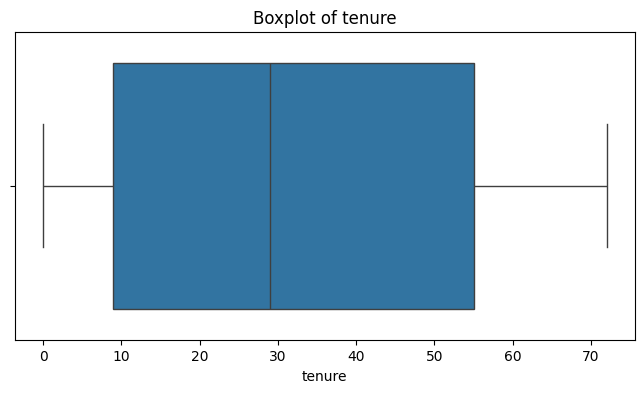

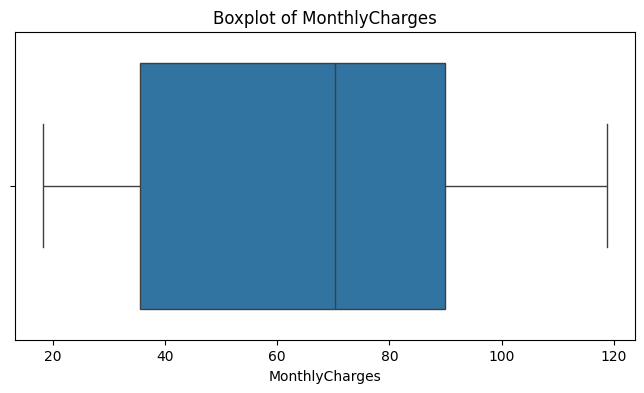

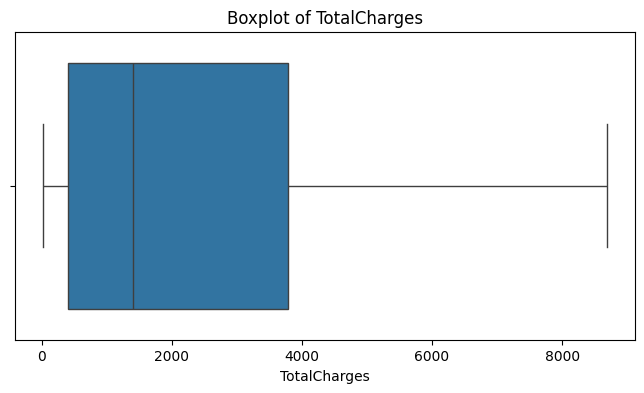

In [11]:
for col in numeric:
    plt.figure(figsize=(8, 4)) # Har plot ka size set karne ke liye
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## OBSERVATIONS: Boxplot show that there is no outliers in Totalcharges,Monthlycharges and Tenure.

## EDA  
1 Analysis Target variables(Univarient analysis)

C:\Users\prime\AppData\Local\Temp\ipykernel_14008\618640009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='pastel')


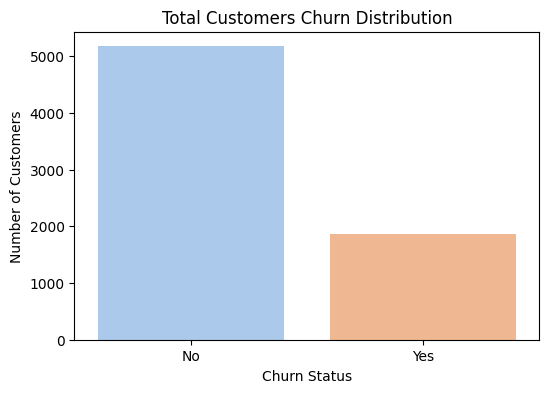

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='pastel')
plt.title('Total Customers Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()
print("Churn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

2 Analysis of categorial coulumn vs  churn (Bivariant analysis)

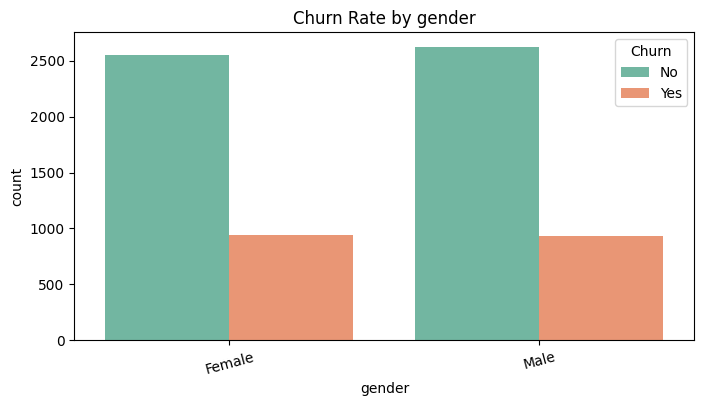

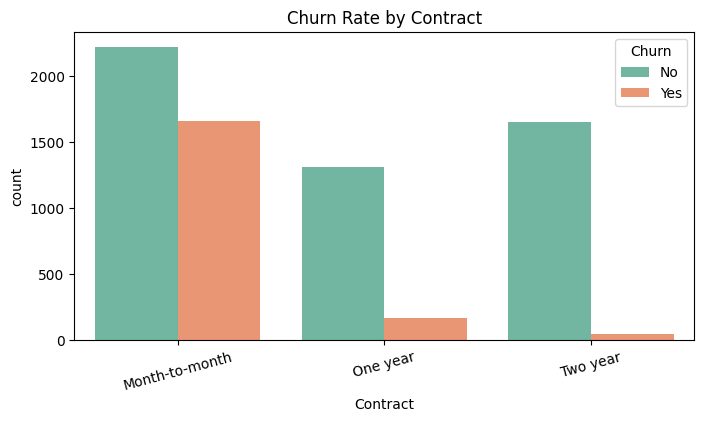

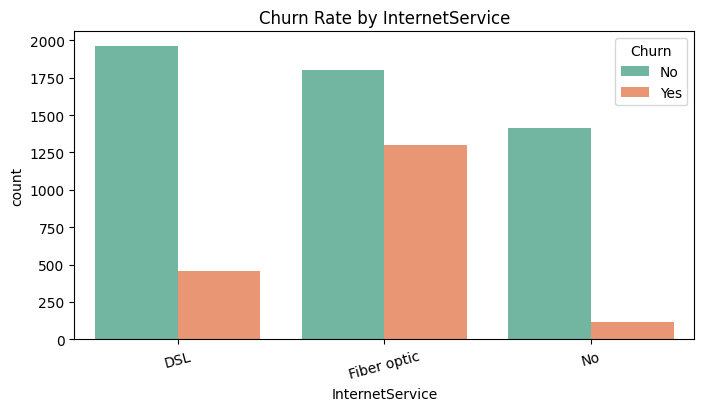

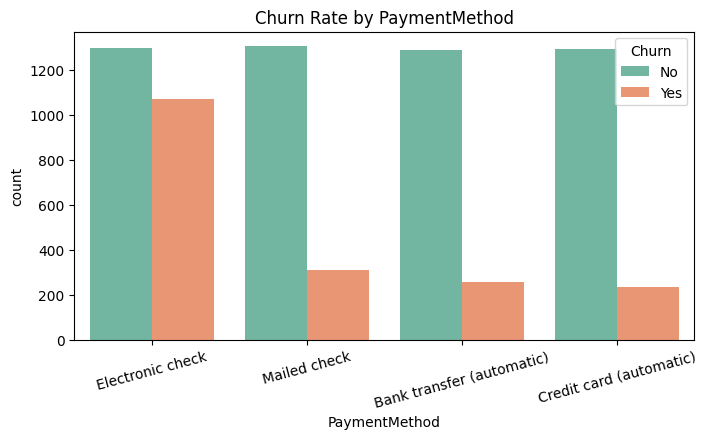

In [13]:
cat_cols = ['gender', 'Contract', 'InternetService', 'PaymentMethod']
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue='Churn', data=df, palette='Set2')
    plt.title(f'Churn Rate by {col}')
    plt.xticks(rotation=15) 
    plt.show()

3 Analysis of numerical column vs churn (Distribution analysis)

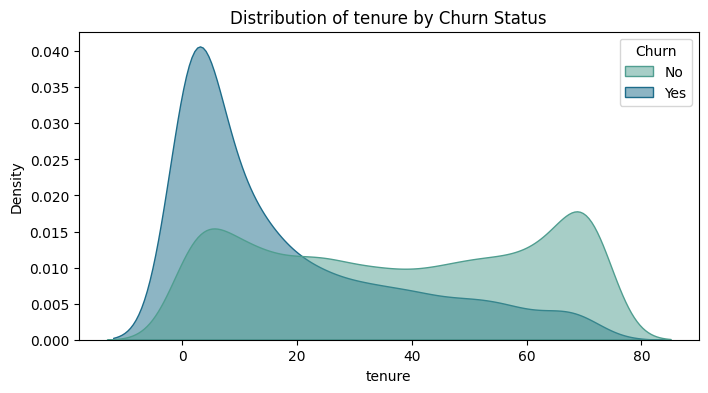

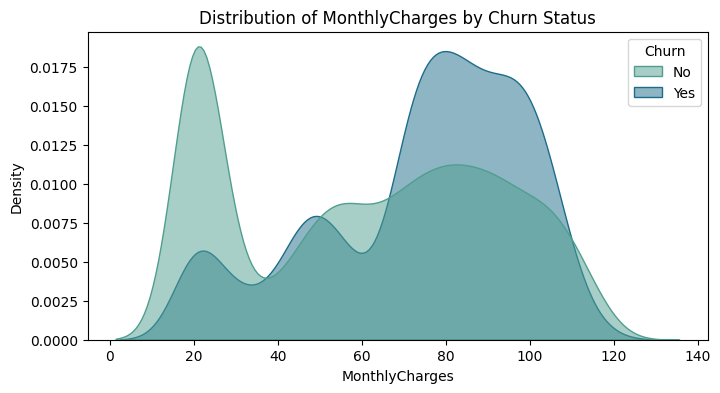

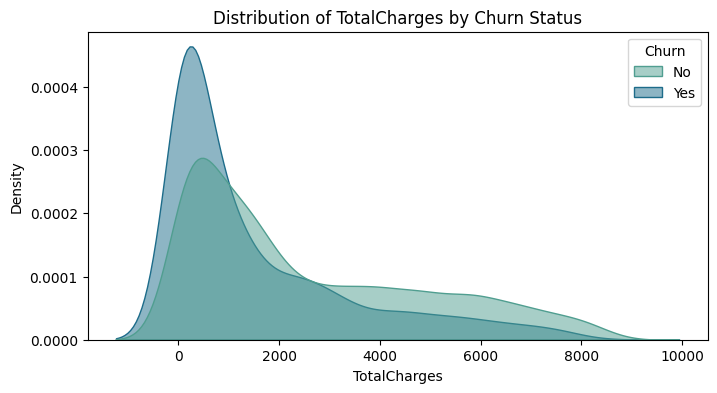

In [14]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, palette='crest', alpha=0.5)
    plt.title(f'Distribution of {col} by Churn Status')
    plt.show()

4 check coorelation matrix ( Heatmap )

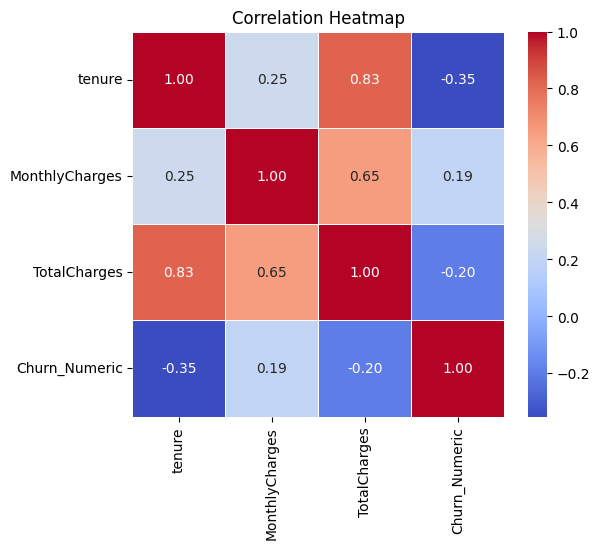

In [15]:
df_temp = df.copy()
df_temp['Churn_Numeric'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})
corr = df_temp[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Feature Engineering   
1 Remove customerId bcs it does not provide pridictive information.  
  it is used only as a identifier.

In [16]:
df.drop(
"customerID",
axis=1,
inplace=True
)

2 TENURE FEATURE: Customers are grouped based on their tenure duration into New, Medium, and Loyal categories to capture customer relationship length.


In [17]:
df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 36, 72],
    labels=["New", "Medium", "Loyal"]
)

3 SERVICE USAGE COUNT: This is new column we create which count that one customer use how many services.

In [18]:
services=[
"PhoneService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
df["Service_Count"]=0
for col in services:
    df["Service_Count"] += (
        df[col]=="Yes"
    ).astype(int)

4 SPENDING BEHAVIOUR FEATURE: Here we calculate average monthly expenditure of customer.

In [19]:
df["Average_Monthly_Spend"]=(
df["TotalCharges"]/
(df["tenure"]+1)
)

5 PAYMENT RISK FEATURE: Here we chek that how customer pay the payment by electronic check or manually by credit card, if it pays by electronic the value should be 1 otherwise 0.

In [20]:
df["Payment_Risk"]=(
df["PaymentMethod"]==
"Electronic check"
).astype(int)

6 CONTRACT RATE: Here we check the customer contract duration.

In [21]:
df["Contract_Risk"]=(
df["Contract"]==
"Month-to-month"
).astype(int)

## Check that updation done correctly or not.

In [22]:
df[['Service_Count', 'Average_Monthly_Spend', 'Payment_Risk', 'Contract_Risk']].head()

,Service_Count,Average_Monthly_Spend,Payment_Risk,Contract_Risk
0,1,14.925000,1,1
1,3,53.985714,0,0
2,3,36.050000,0,1
3,3,40.016304,0,0
4,1,50.550000,1,1


## Complete Visualisation of highly impact categorial and numerical column.

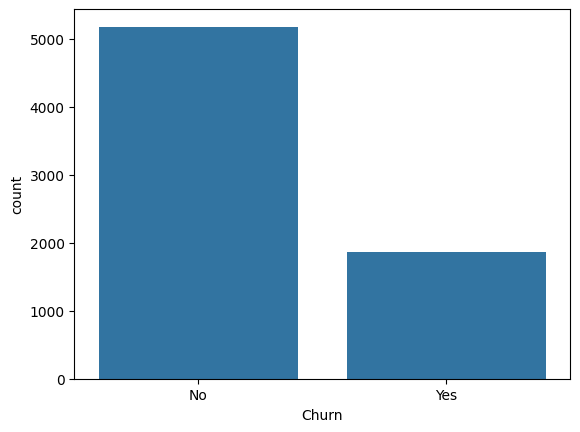

In [23]:
# CHURN DISTRIBUTION
sns.countplot(
x="Churn",
data=df
)
plt.show()

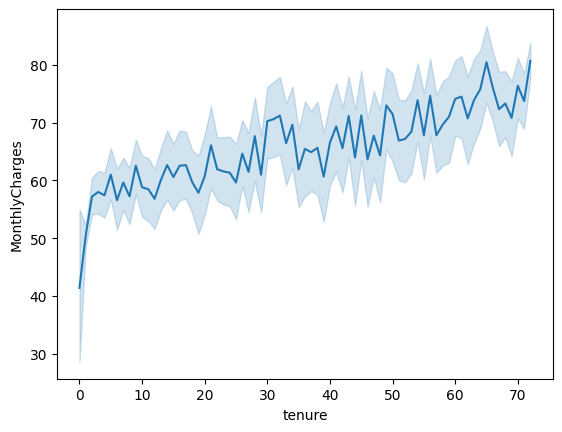

In [24]:
# REVINUE TREND
sns.lineplot(
x="tenure",
y="MonthlyCharges",
data=df
)
plt.show()

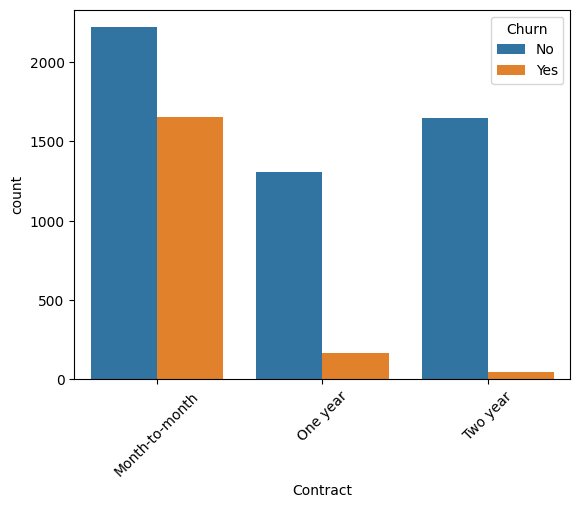

In [25]:
# CONTRACT WISE CHURN 
sns.countplot(
x="Contract",
hue="Churn",
data=df
)
plt.xticks(rotation=45)
plt.show()

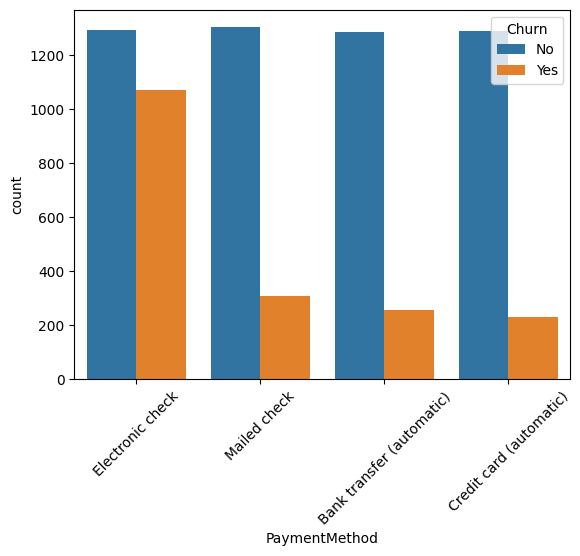

In [26]:
# PAYMENT METHOD ANALYSIS
sns.countplot(
x="PaymentMethod",
hue="Churn",
data=df
)
plt.xticks(rotation=45)
plt.show()

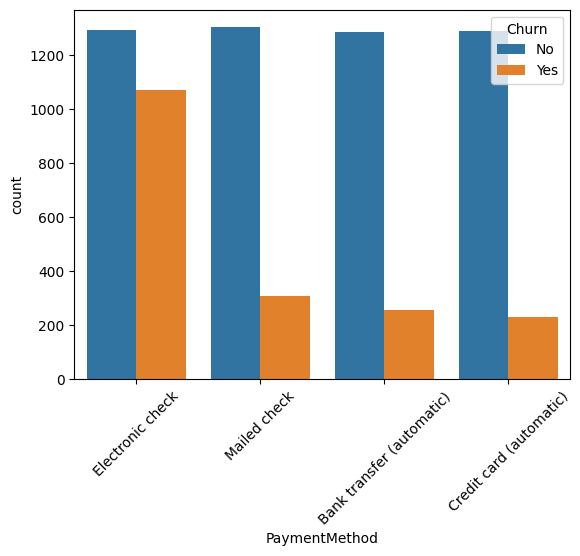

In [27]:
# INTERNET SERVICE ANALYSIS
sns.countplot(
x="PaymentMethod",
hue="Churn",
data=df
)
plt.xticks(rotation=45)
plt.show()

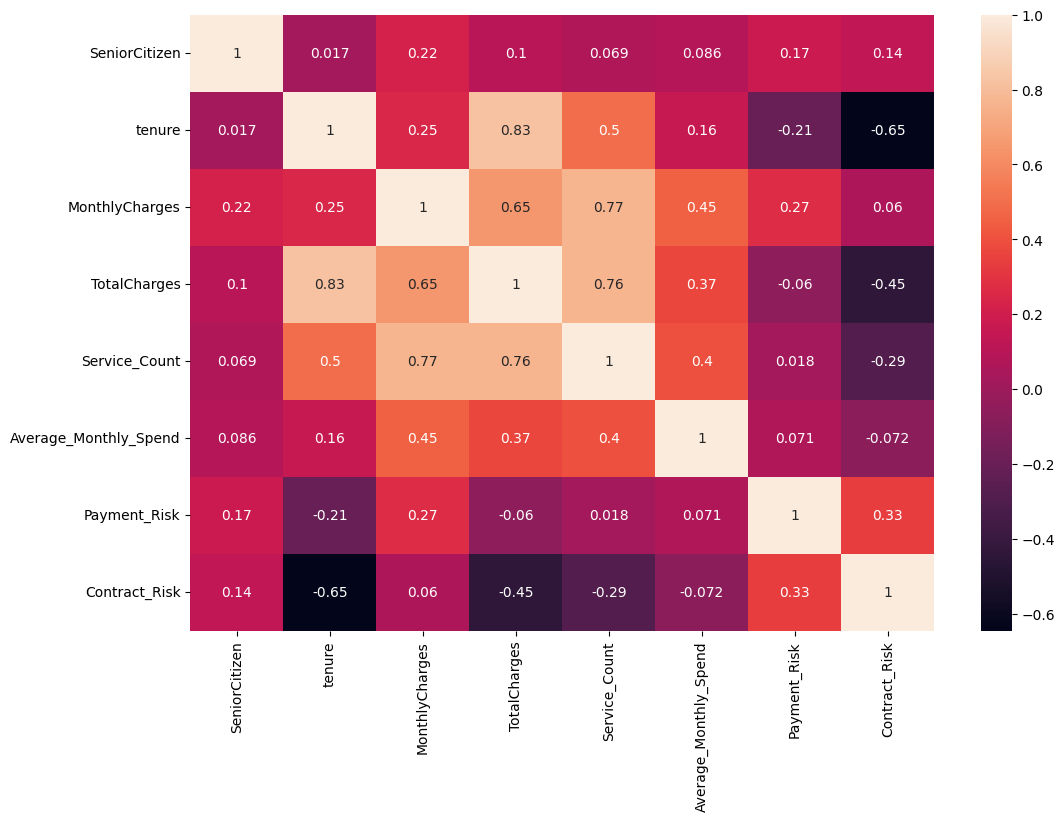

In [28]:
# CORELATION HEATMAP
plt.figure(
figsize=(12,8)
)
sns.heatmap(
df.corr(numeric_only=True),
annot=True
)
plt.show()

## Customer Segmentation (create a groups)

##  1 Calculate customer score

In [29]:

df["Customer_Score"] = (
    (df["tenure"] / 72 * 40) +
    (df["MonthlyCharges"] / df["MonthlyCharges"].max() * 30) +
    (df["Service_Count"] / 7 * 30)
)

## 2 Apply segmentation function

In [30]:
def segment(score):
    if score >= 70:
        return "High Value"
    elif score >= 40:
        return "Medium Value"
    else:
        return "Low Value"

## Apply function on all rows

In [31]:
df["Customer_Segment"] = df["Customer_Score"].apply(segment)

## Check distribution by graphs.

C:\Users\prime\AppData\Local\Temp\ipykernel_14008\2037689589.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Customer_Segment", data=df, order=["High Value", "Medium Value", "Low Value"], palette="viridis")


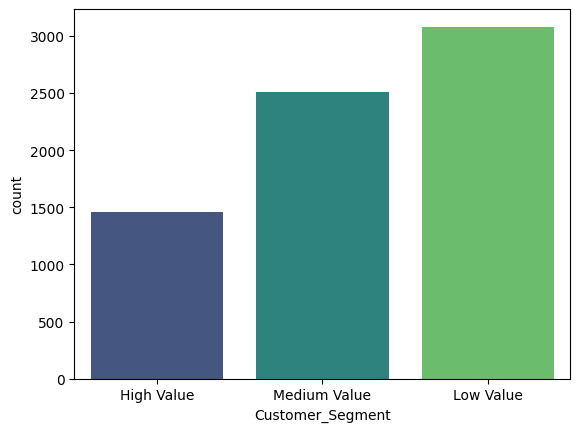

In [32]:
sns.countplot(x="Customer_Segment", data=df, order=["High Value", "Medium Value", "Low Value"], palette="viridis")
plt.show()

## ENCODING: One Hot Encodeing converts texual column into 0 and 1 numeric column. we do this step bcz ML model not understand categorial column.     

In [33]:
df=pd.get_dummies(
df,
drop_first=True
)

## Split data

In [34]:
X=df.drop("Churn_Yes",axis=1)
y=df["Churn_Yes"]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

### Appply standardscaler before training ML model

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## TRAIN MODELS  
1 LOGISTIC REGRESSION

In [36]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = lr.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.8062455642299503

Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.90      0.87      1036
        True       0.66      0.55      0.60       373

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### 2 RANDOM FOREST

In [38]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
from sklearn.metrics import accuracy_score, classification_report
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7899219304471257

Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.90      0.86      1036
        True       0.64      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



## MODEL EVALUATION

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
def evaluation(model, X_test_data):
    pred = model.predict(X_test_data)
    probability = model.predict_proba(X_test_data)[:, 1]
    print(f"Accuracy:  {accuracy_score(y_test, pred):.4f}")
    print(f"Precision: {precision_score(y_test, pred):.4f}")
    print(f"Recall:    {recall_score(y_test, pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, probability):.4f}")

### Compare Models

In [41]:
print("--- LOGISTIC REGRESSION PERFORMANCE ---")
evaluation(lr, X_test_scaled)
print("\n--- RANDOM FOREST PERFORMANCE ---")
evaluation(rf, X_test)

--- LOGISTIC REGRESSION PERFORMANCE ---
Accuracy:  0.8062
Precision: 0.6613
Recall:    0.5496
F1 Score:  0.6003
ROC-AUC:   0.8615

--- RANDOM FOREST PERFORMANCE ---
Accuracy:  0.7899
Precision: 0.6400
Recall:    0.4718
F1 Score:  0.5432
ROC-AUC:   0.8425


### Final Model Comparison Report

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | **0.8062** | **0.6613** | **0.5496** | **0.6003** | **0.8615** |
| **Random Forest** | 0.7899 | 0.6400 | 0.4718 | 0.5432 | 0.8425 |

### Conclusion:
**Logistic Regression** is the clear winner as it outperforms Random Forest in every metric, especially **Recall (0.5496)** and **ROC-AUC (0.8615)**, which are crucial for predicting customer churn.

## Feature Importance (Model Explainabilty)  
This module extracts and ranks the top 10 most influential features from the Random Forest model to identify the primary business drivers behind customer churn.

In [42]:
importance=pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_})
importance.sort_values(by="Importance",ascending=False).head(10)

,Feature,Importance
3,TotalCharges,0.117322
1,tenure,0.111771
2,MonthlyCharges,0.110226
8,Customer_Score,0.106010
5,Average_Monthly_Spend,0.105678
7,Contract_Risk,0.048671
15,InternetService_Fiber optic,0.032304
4,Service_Count,0.024754
31,PaperlessBilling_Yes,0.020711
9,gender_Male,0.020620


## Churn Pridiction System: Real time pridiction function that calculates exact churn probabilty for any individual customer.

In [43]:
def predict_customer(data):
    probability = rf.predict_proba(data)[0][1]
    if probability < 0.3:
        risk = "Low Risk"
    elif probability < 0.7:
        risk = "Medium Risk"
    else:
        risk = "High Risk"   
    return probability, risk

In [44]:
sample_customer = X_test.iloc[[0]]
prob, risk_level = predict_customer(sample_customer)
print(f"Churn Probability: {prob:.2%}")
print(f"Risk Assessment:  {risk_level}")

Churn Probability: 74.50%
Risk Assessment:  High Risk


##  Business Insights Report

### 1. Top Churn Reasons
* **Month-to-month Contracts:** Customers on month-to-month plans show significantly higher churn due to lack of long-term commitment features.
* **Electronic Payment Methods:** Manual payment via electronic check is strongly linked with higher churn behavior.
* **New Customers (Low Tenure):** Freshly acquired customers have a much higher churn probability before hitting their stability milestone.
* **Lack of Support Services:** Customers without features like TechSupport or OnlineSecurity leave the company more frequently.

---

### 2. High Risk Customer Profile
Based on our machine learning analysis, a typical **High-Risk Customer** fits the following criteria:
* **Low Tenure:** Often within their first few months of subscription.
* **High Monthly Charges:** Getting billed high amounts without long-term contracts.
* **No TechSupport:** Missing key auxiliary retention services.
* **Month-to-month Contract:** Free to leave at any billing cycle.
* **Few Subscribed Services:** Low `Service_Count` score (low reliance on the ecosystem).

---

### 3. Revenue Impact Analysis

To calculate the financial damage caused by customer attrition, we use the following business formula:

$$Revenue\ Loss = Number\ of\ Churned\ Customers \times Average\ Monthly\ Charges$$

#### Strategic Recommendation:
By implementing our **Logistic Regression Model**, the business can automatically flag these high-risk profiles at a **74.50% probability threshold** (as demonstrated in Module 8) and proactively offer incentives (like shifting them from month-to-month to a discounted 1-year contract with free TechSupport) to prevent revenue leakage.

## SAVE MODELS

In [46]:
import pickle
import os

# 1. 'models' naam ka folder banayein agar pehle se nahi bana
os.makedirs("models", exist_ok=True)

# 2. Logistic Regression (lr) aur Scaler ko save karein
with open("models/logistic_model.pkl", "wb") as f:
    pickle.dump(lr, f)

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Models successfully saved inside models/ folder! 🎉")

Models successfully saved inside models/ folder! 🎉
